In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from pydantic import Field, BaseModel
from typing import TypedDict, List, Optional
from dotenv import load_dotenv

load_dotenv()

class GraphState(TypedDict):
    topic: Optional[str]
    draft : str
    improvement: str
    score: int
    iteration: int


llm = ChatOpenAI(model = "gpt-4o-mini")

class Evaluator(BaseModel):
    score: int = Field(description="The overall score 1-10", ge=1, le=10)
    feedback: str = Field(description="improvements feedback in a bullet points")

def generate(state:GraphState):
    total_generation = state.get('iteration', 0)
    print('generating content...')
    if not total_generation:
        print('generating First Draft...')
        prompt = f"""
            generate a robust and professionally written content abou this topic
            topic:
            {state['topic']}
            """
        response = llm.invoke(prompt).content
        return {
            'draft': response,
            'iteration': 1
        }
    else:
        print(f'generating draft number {total_generation}')
        prompt = f"""
    take a look at this content. based on the suggested improvements can you rewrite this content
    content:
    {state['draft']}

    suggested improvements:
    {state['improvement']}

    """
        response = llm.invoke(prompt).content
        return {
            "draft": response,
            "iteration": state.get('improvement', 0) + 1
        }


def improver(state:GraphState)->GraphState:
    print(f'Improving Content...\n {state['draft'][30]}...')
    prompt = f"""
        The content below is for a professional organization. 

        content:
        {state['draft']}

        Task:
        Based on the content can you suggest
        - a list of improvements that needs to be done to this content as feedback
        - rate the content from 1-10
        - let the improvement suggestions be concise but well understood
        """
    
    structured_llm = llm.with_structured_output(Evaluator)

    response = structured_llm.invoke(prompt)

    return {
        'improvement':response.feedback,
        'score':response.score
    }


def should_continue(state:GraphState):
    if state['iteration'] > 3:
        return "end" 
    elif state['score'] >= 8:
        return "end"
    else:
        return "generate"
    





    

In [13]:
builder = StateGraph(GraphState)

builder.add_node("generate", generate)
builder.add_node("improver", improver)

builder.add_edge(START, "generate")
builder.add_edge("generate", "improver")
builder.add_conditional_edges(
    "improver",
    should_continue,
    {
        "generate": "generate",
        "end": END
    }

)

graph = builder.compile()

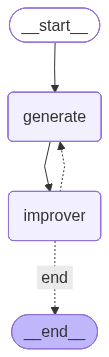

In [10]:
graph

In [ ]:
# class GraphState(TypedDict):
#     topic: Optional[str]
#     draft : str
#     improvement: str
#     score: int
#     iteration: int


response  = graph.invoke({
    "topic": "Leadership Meetings"
})

print(response['draft'])



generating content...
generating First Draft...
Improving Content...
 r...


c:\lang1\venvi\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Evaluator(score=8, feedba...ld to add credibility.'), input_type=Evaluator])
  return self.__pydantic_serializer__.to_python(


In [17]:
print(response['score'])

8
